In [200]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as sps

In [ ]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

# 1. Generate the raw, highly overdispersed Negative Binomial map
np.random.seed(42)
mu = 0.5
r = 2.0
p = r / (r + mu) # conversion to standard probability notation

# nbinom.rvs returns integers
raw_map = np.float32(np.random.negative_binomial(n=r, p=p, size=(8000, 4000)))

In [273]:
# 2. Apply the continuous Gaussian filter (size n pixels)
n_pix = 3.0
smoothed_map = gaussian_filter(raw_map, sigma=n_pix)

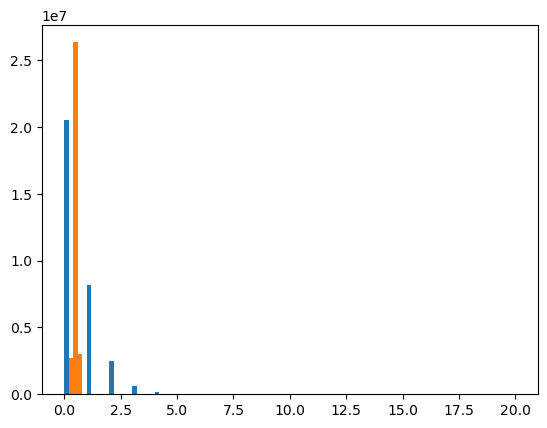

In [274]:
plt.hist(raw_map.flatten(), bins=100, range=[0, 20])
plt.hist(smoothed_map.flatten(), bins=100, range=[0, 20])
plt.show()

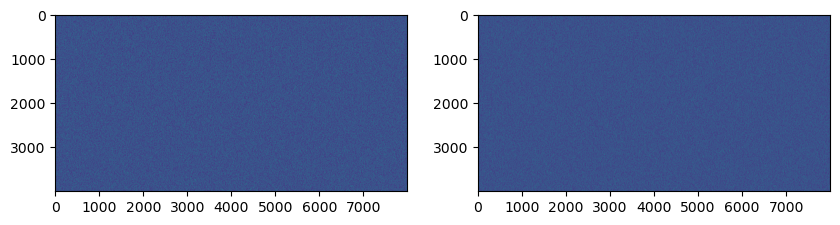

In [276]:
plt.figure(figsize=(10, 5))
plt.subplot(121)
plt.imshow(raw_map.T, vmin=0, vmax=2)
plt.subplot(122)
plt.imshow(smoothed_map.T, vmin=0, vmax=2)

In [277]:
# Subsample the map every 4*n_pix to remove spatial correlation artifacts:
stride = int(4 * n_pix)
data = smoothed_map[::stride, ::stride].flatten()

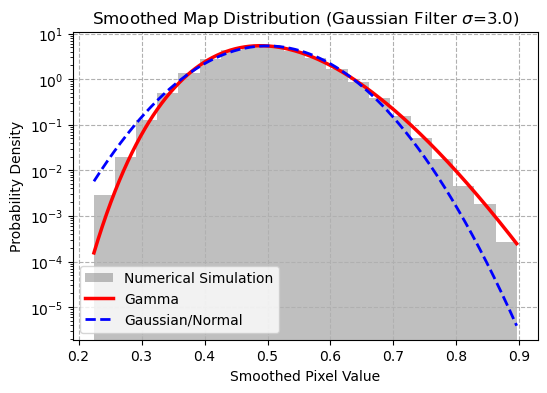

In [279]:
# 3. Calculate empirical parameters of the smoothed map
mean_smooth = np.mean(data)
var_smooth = np.var(data)

# 4. Define our distribution models based on those exact moments
# A) Gamma Model: shape (alpha) and scale (beta) matched to the data
alpha_fit = (mean_smooth**2) / var_smooth
beta_fit = var_smooth / mean_smooth

# B) Normal/Gaussian Model: using the data's mean and variance
norm_mu = mean_smooth
norm_sigma = np.sqrt(var_smooth)

# 5. Plot the visual proof
plt.figure(figsize=(6, 4))
counts, bins, _ = plt.hist(data, bins=20, density=True, alpha=0.5, color='gray', label='Numerical Simulation')

# Generate an x-axis grid for the continuous PDFs
x_grid = np.linspace(bins[0], bins[-1], 1000)

plt.plot(x_grid, stats.gamma.pdf(x_grid, a=alpha_fit, scale=beta_fit), 'r-', lw=2.5, label='Gamma')
plt.plot(x_grid, stats.norm.pdf(x_grid, loc=norm_mu, scale=norm_sigma), 'b--', lw=2, label='Gaussian/Normal')

plt.yscale('log') # Log scale to aggressively inspect the tails!
plt.title(f'Smoothed Map Distribution (Gaussian Filter $\sigma$={n_pix})')
plt.xlabel('Smoothed Pixel Value')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(True, ls='--')
plt.show()

### Wilson-Hilferty transformation check

$$ x\propto \Gamma(a_x, \theta_x) \to t = 2x/\theta_x \propto \chi^2(n=2a) \to Z = \dfrac{(t/2a_x)^{1/3} - (1-1/9a_x)}{\sqrt{1/9a_x}} $$

In [203]:
# Sample gamma distribution

a1, theta1 = 1.5, 2.7
gamma1 = sps.gamma(a=a1, scale=theta1)
x_gamma1 = gamma1.rvs(10000)
t_gamma1 = 2 * x_gamma1 / theta1

a2, theta2 = 2.1, 5.4
gamma2 = sps.gamma(a=a2, scale=theta2)
y_gamma2 = gamma2.rvs(10000)
t_gamma2 = 2 * y_gamma2 / theta2

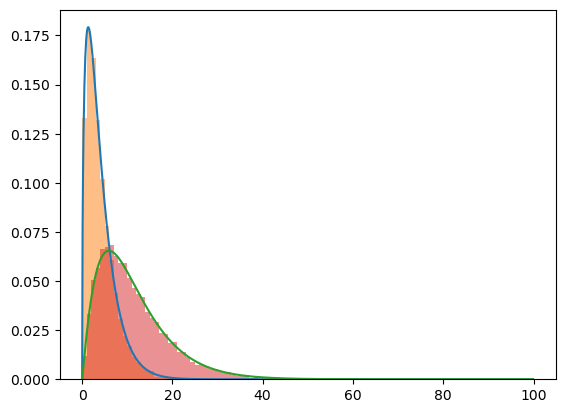

In [204]:
x = np.arange(0, 100, 0.1)
bins = np.arange(0, 40, 1)
plt.plot(x, gamma1.pdf(x))
plt.hist(x_gamma1, density=True, bins=bins, alpha=.5)

plt.plot(x, gamma2.pdf(x))
plt.hist(y_gamma2, density=True, bins=bins, alpha=.5)
plt.show()

$$ x\propto \Gamma(a_x, \theta_x) \to t = 2x/\theta_x \propto \chi^2(n=2a) $$

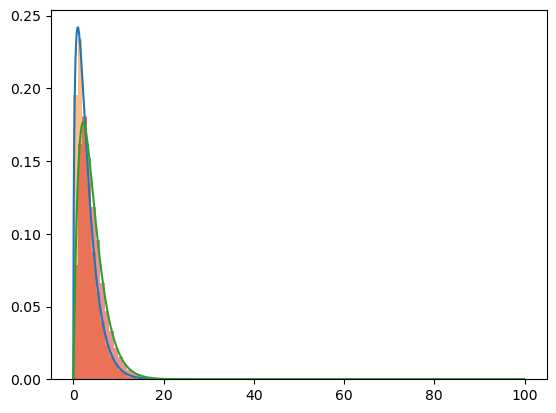

In [205]:
chi21 = sps.chi2(2*a1)
plt.plot(x, chi21.pdf(x))
plt.hist(t_gamma1, density=True, bins=bins, alpha=.5)

chi22 = sps.chi2(2*a2)
plt.plot(x, chi22.pdf(x))
plt.hist(t_gamma2, density=True, bins=bins, alpha=.5)
plt.show()

$$ t = 2x/\theta_x \propto \chi^2(n=2a) \to Z = \dfrac{(t/2a_x)^{1/3} - (1-1/9a_x)}{\sqrt{1/9a_x}} $$

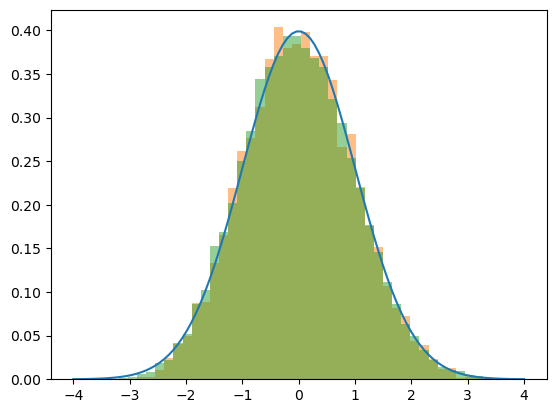

In [206]:
z_gamma1 = ((t_gamma1/(2*a1))**(1/3) - (1 - 1/(9*a1))) * np.sqrt(9*a1)
z_gamma2 = ((t_gamma2/(2*a2))**(1/3) - (1 - 1/(9*a2))) * np.sqrt(9*a2)

x0 = np.linspace(-4, 4, 100)
norm = sps.norm()
plt.plot(x0, norm.pdf(x0))
plt.hist(z_gamma1, bins=x0[::2], alpha=.5, density=True)
plt.hist(z_gamma2, bins=x0[::2], alpha=.5, density=True)
plt.show()

Finally, backward: $Y_x = \theta_y a_y \left[ \sqrt{1/9a_y} Z_x + (1-1/9a_y) \right]^3$

In [207]:
y_x = theta2 * a2 * (np.sqrt(1/(9*a2)) * z_gamma1 + (1-1/(9*a2)))**3

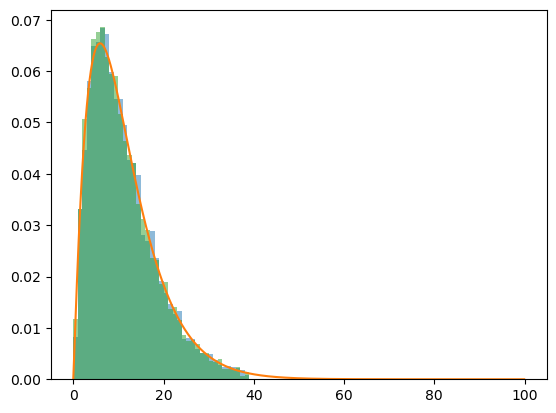

In [208]:
plt.hist(y_x, density=True, bins=bins, alpha=.5)
plt.plot(x, gamma2.pdf(x))
plt.hist(y_gamma2, density=True, bins=bins, alpha=.5)
plt.show()

**SUCCESS!!!**

This now gives an approximation of the transform in the following form:

$$ Y_x = \theta_y a_x \sqrt{\frac{a_x}{a_y}} \left[ \left(\frac{x}{a_x \theta_x}\right)^{1/3} + \xi \right]^3,\quad \xi = \left( \sqrt{\frac{a_y}{a_x}} - 1 \right) \left( \frac{1}{9\sqrt{a_x a_y}} + 1 \right) $$

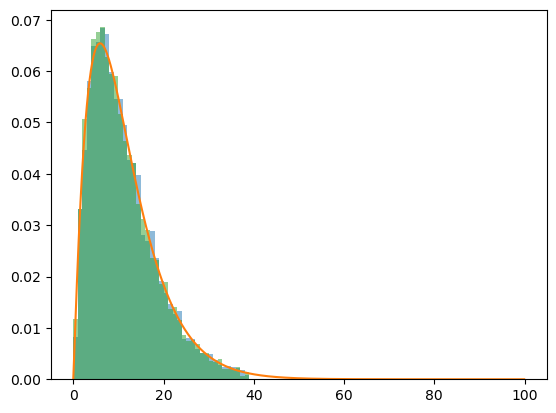

In [209]:
xi = (np.sqrt(a2/a1) - 1) * (1/(9*np.sqrt(a1*a2)) + 1)
y_x2 = theta2 * a1 * np.sqrt(a1/a2) * ((x_gamma1/(a1*theta1))**(1/3) + xi)**3
# y_x2 = theta2 * a2 * (np.sqrt(a1/a2) * ((x_gamma1/(a1*theta1))**(1/3) - (1 - 1/(9*a1))) + (1 - 1/(9*a2)))**(3)

# plt.hist(y_x, density=True, bins=bins, alpha=.5)
plt.hist(y_x2, density=True, bins=bins, alpha=.5)
plt.plot(x, gamma2.pdf(x))
plt.hist(y_gamma2, density=True, bins=bins, alpha=.5)
plt.show()

Finally, we want to compare our function with the general approach

$$ g = F_Y^{-1} \circ F_X  $$

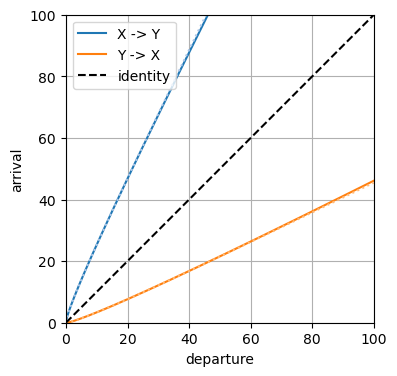

In [216]:
from config.plotting import Tab10, Tab20

xi_fwd = (np.sqrt(a2/a1) - 1) * (1/(9*np.sqrt(a1*a2)) + 1)
xi_bkw = (np.sqrt(a1/a2) - 1) * (1/(9*np.sqrt(a1*a2)) + 1)

x_fwd = theta2 * a1 * np.sqrt(a1/a2) * ((x/(a1*theta1))**(1/3) + xi_fwd)**3
bkw = theta1 * a2 * np.sqrt(a2/a1) * ((x/(a2*theta2))**(1/3) + xi_bkw)**3

plt.figure(figsize=(4, 4))

# forward
plt.plot(x, x_fwd, label='X -> Y', color=Tab20[0])
def g_fwd(t):
    F_Ym = gamma2.ppf
    F_X = gamma1.cdf
    return F_Ym(F_X(t))
plt.plot(x, g_fwd(x), color=Tab20[1], linestyle='dotted')

# backward
plt.plot(x, bkw, label='Y -> X', color=Tab20[2])
def g_bkw(t):
    F_Ym = gamma1.ppf
    F_X = gamma2.cdf
    return F_Ym(F_X(t))
plt.plot(x, g_bkw(x), color=Tab20[3], linestyle='dotted')

plt.plot(x, x, linestyle='dashed', color='k', label='identity')

plt.xlim(0, 100)
plt.xlabel('departure')

plt.ylim(0, 100)
plt.ylabel('arrival')

plt.gca().set_aspect('equal')

plt.legend(loc='upper left')
plt.grid()
plt.show()